In [1]:
from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA
from statsforecast.utils import AirPassengersDF
import pandas as pd


c:\Users\AFROCHEM\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df=AirPassengersDF
sf=StatsForecast(models=[AutoARIMA(season_length=12)],freq='ME',)
X=df.iloc[:100]
y=df.iloc[100:]
sf.fit(X)
y_pred=sf.predict(h=len(y))

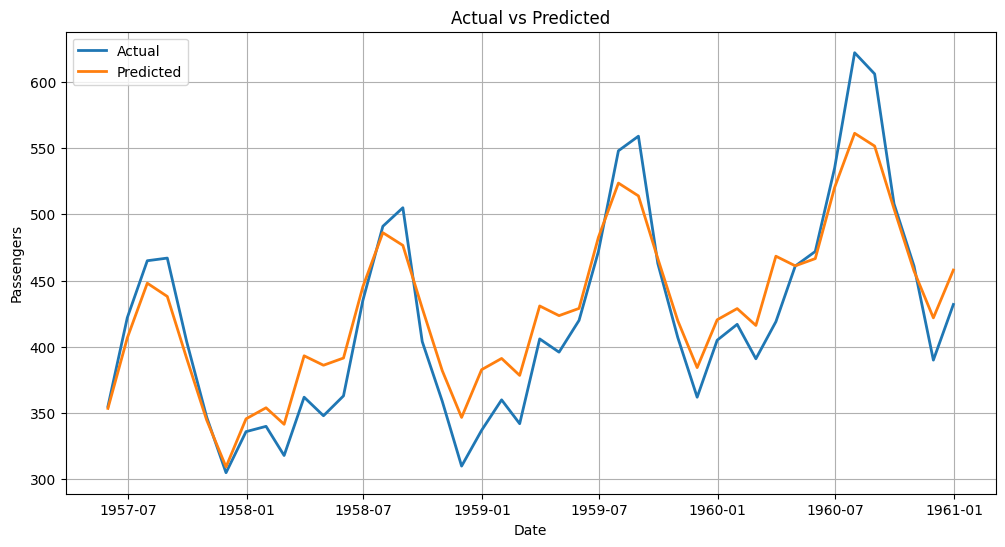

In [3]:
import matplotlib.pyplot as plt
actual = y.copy()

# Predicted values
pred = y_pred.copy()

plt.figure(figsize=(12,6))

# plot actual
plt.plot(actual['ds'], actual['y'], label='Actual', linewidth=2)

# plot predicted
plt.plot(pred['ds'], pred['AutoARIMA'], label='Predicted', linewidth=2)

plt.xlabel("Date")
plt.ylabel("Passengers")
plt.title("Actual vs Predicted")
plt.legend()
plt.grid(True)
plt.show()



<>:13: SyntaxWarning: invalid escape sequence '\m'
<>:16: SyntaxWarning: invalid escape sequence '\m'
<>:19: SyntaxWarning: invalid escape sequence '\m'
<>:23: SyntaxWarning: invalid escape sequence '\m'
<>:13: SyntaxWarning: invalid escape sequence '\m'
<>:16: SyntaxWarning: invalid escape sequence '\m'
<>:19: SyntaxWarning: invalid escape sequence '\m'
<>:23: SyntaxWarning: invalid escape sequence '\m'
C:\Users\AFROCHEM\AppData\Local\Temp\ipykernel_31144\674625183.py:13: SyntaxWarning: invalid escape sequence '\m'
  plt.plot(x, norm.pdf(x, 0, 1), label='$\mu=0, \sigma=1$ (Standard)', lw=3)
C:\Users\AFROCHEM\AppData\Local\Temp\ipykernel_31144\674625183.py:16: SyntaxWarning: invalid escape sequence '\m'
  plt.plot(x, norm.pdf(x, 3, 1), label='$\mu=3, \sigma=1$ (Shifted Right)', lw=2)
C:\Users\AFROCHEM\AppData\Local\Temp\ipykernel_31144\674625183.py:19: SyntaxWarning: invalid escape sequence '\m'
  plt.plot(x, norm.pdf(x, 0, 3), label='$\mu=0, \sigma=3$ (Spread Out)', lw=2, linestyle='-

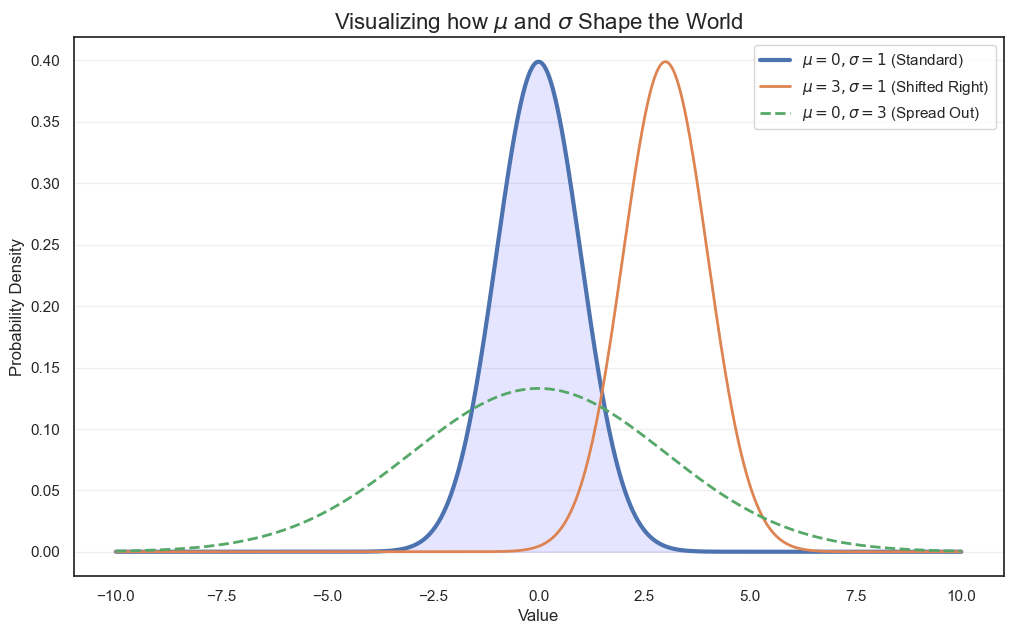

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

sns.set_theme(style="white")
plt.figure(figsize=(12, 7))

x = np.linspace(-10, 10, 1000)


# Standard Normal (Mean=0, Std=1)
plt.plot(x, norm.pdf(x), label='$\mu=0, \sigma=1$ (Standard)', lw=3)

# Shifted Mean (Mean=3, Std=1)
plt.plot(x, norm.pdf(x, 3, 1), label='$\mu=3, \sigma=1$ (Shifted Right)', lw=2)

# High Variance (Mean=0, Std=3)
plt.plot(x, norm.pdf(x, 0, 3), label='$\mu=0, \sigma=3$ (Spread Out)', lw=2, linestyle='--')


plt.fill_between(x, norm.pdf(x, 0, 1), alpha=0.1, color='blue') # Shade the Standard Normal
plt.title("Visualizing how $\mu$ and $\sigma$ Shape the World", fontsize=16)
plt.xlabel("Value", fontsize=12)
plt.ylabel("Probability Density", fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

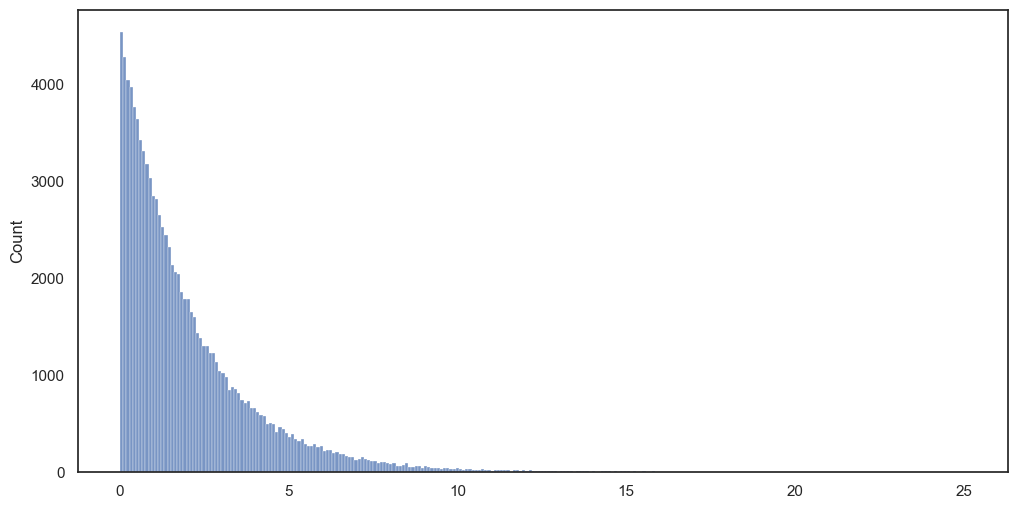

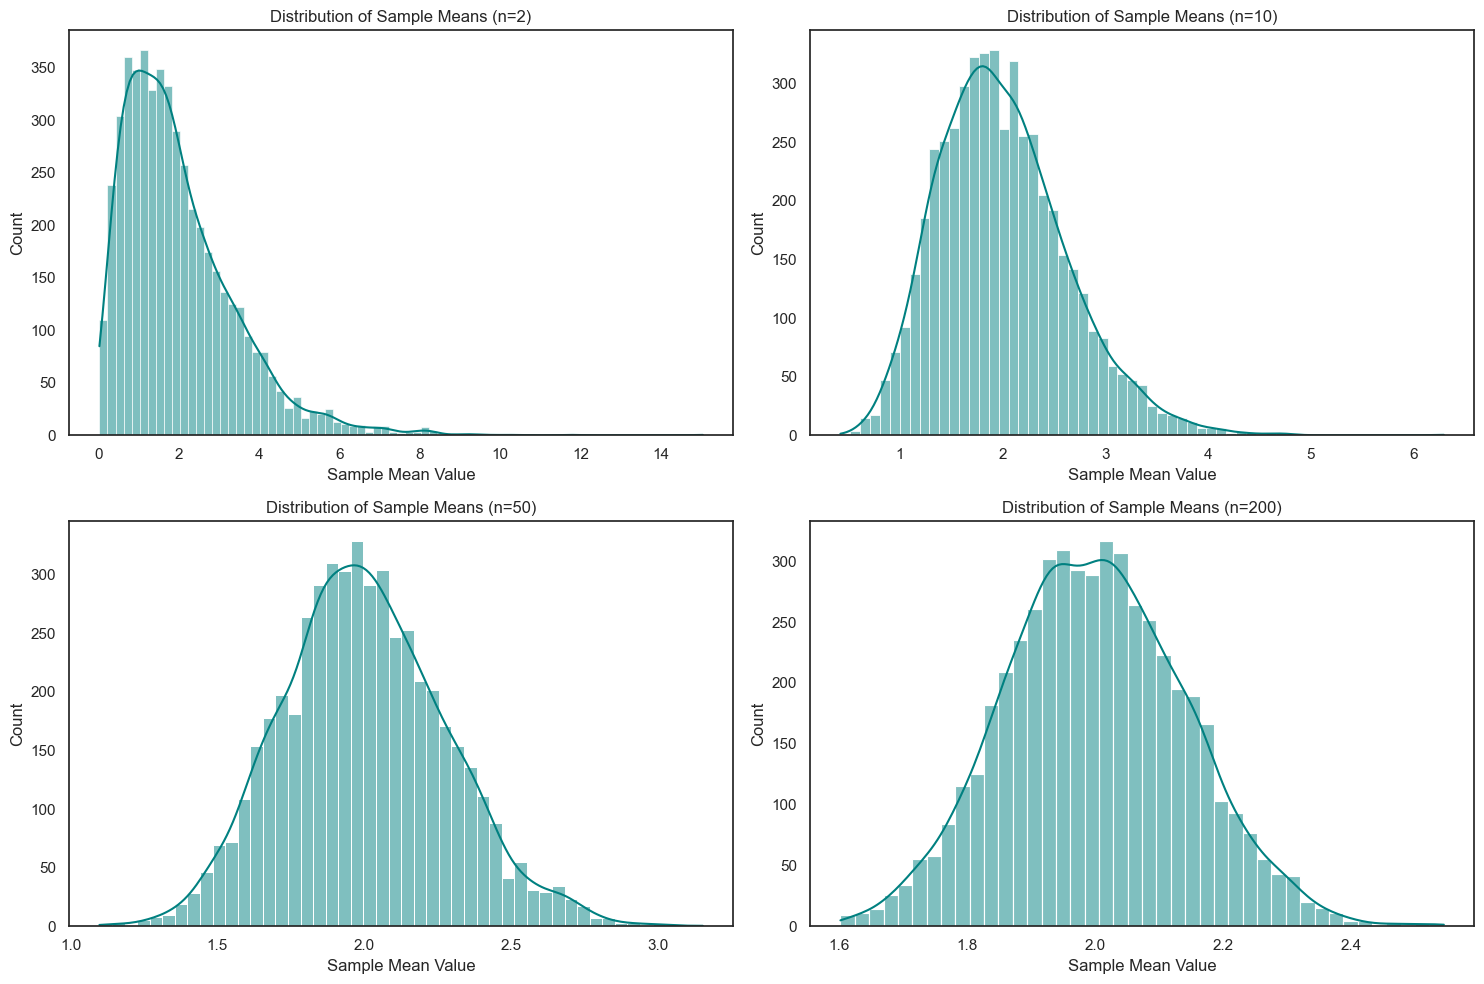

In [17]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Create a "Messy" Population (Exponential Distribution)
# This looks nothing like a Bell Curve!
population = np.random.exponential(scale=2, size=100000)
plt.figure(figsize=(12,6))
sns.histplot(population)

def simulate_clt(data, sample_size, iterations):
    means = []
    for _ in range(iterations):
        sample = np.random.choice(data, size=sample_size)
        means.append(np.mean(sample))
    return means

# 2. Run simulations for different sample sizes (n)
n_values = [2, 10, 50, 200]
plt.figure(figsize=(15, 10))

for i, n in enumerate(n_values):
    plt.subplot(2, 2, i+1)
    sample_means = simulate_clt(population, n, 5000)
    sns.histplot(sample_means, kde=True, color="teal")
    plt.title(f'Distribution of Sample Means (n={n})')
    plt.xlabel('Sample Mean Value')

plt.tight_layout()
plt.show()

<>:15: SyntaxWarning: invalid escape sequence '\p'
<>:21: SyntaxWarning: invalid escape sequence '\P'
<>:15: SyntaxWarning: invalid escape sequence '\p'
<>:21: SyntaxWarning: invalid escape sequence '\P'
C:\Users\AFROCHEM\AppData\Local\Temp\ipykernel_31144\3473454255.py:15: SyntaxWarning: invalid escape sequence '\p'
  sns.lineplot(x=x, y=pdf, ax=ax1, color='blue', label='PDF $\phi(z)$ (Probability Density)')
C:\Users\AFROCHEM\AppData\Local\Temp\ipykernel_31144\3473454255.py:21: SyntaxWarning: invalid escape sequence '\P'
  sns.lineplot(x=x, y=cdf, ax=ax2, color='red', label='CDF $\Phi(z)$ (Accumulated Area)', linestyle='--')


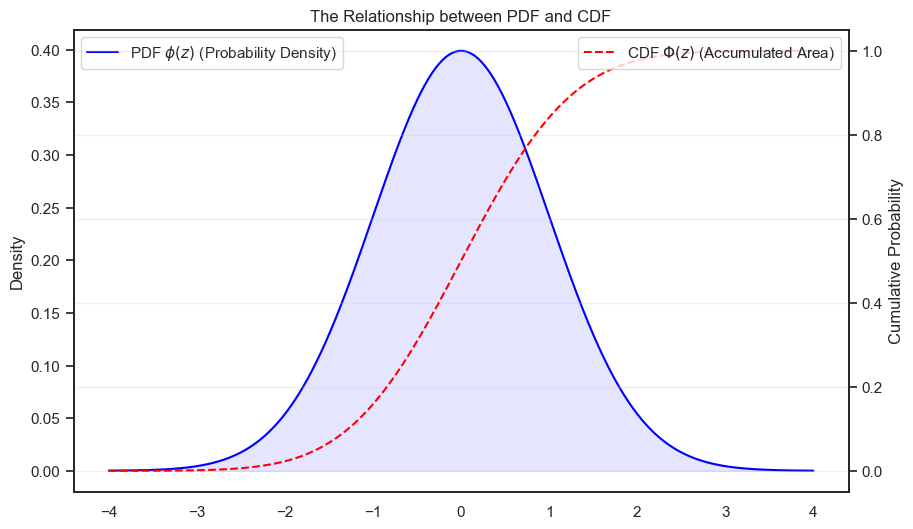

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm


x = np.linspace(-4, 4, 1000)
pdf = norm.pdf(x)
cdf = norm.cdf(x)

# Plotting
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot PDF
sns.lineplot(x=x, y=pdf, ax=ax1, color='blue', label='PDF $\phi(z)$ (Probability Density)')
ax1.fill_between(x, pdf, alpha=0.1, color='blue')
ax1.set_ylabel('Density')

# Create a second y-axis for the CDF
ax2 = ax1.twinx()
sns.lineplot(x=x, y=cdf, ax=ax2, color='red', label='CDF $\Phi(z)$ (Accumulated Area)', linestyle='--')
ax2.set_ylabel('Cumulative Probability')

plt.title('The Relationship between PDF and CDF')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.grid(alpha=0.3)
plt.show()

<>:13: SyntaxWarning: invalid escape sequence '\p'
<>:18: SyntaxWarning: invalid escape sequence '\p'
<>:13: SyntaxWarning: invalid escape sequence '\p'
<>:18: SyntaxWarning: invalid escape sequence '\p'
C:\Users\AFROCHEM\AppData\Local\Temp\ipykernel_31144\379165365.py:13: SyntaxWarning: invalid escape sequence '\p'
  sns.lineplot(x=x, y=standard_pdf, ax=ax1, color='blue', label='PDF $\phi(z)$ (Standard Probability Density)')
C:\Users\AFROCHEM\AppData\Local\Temp\ipykernel_31144\379165365.py:18: SyntaxWarning: invalid escape sequence '\p'
  sns.lineplot(x=x, y=general_pdf, ax=ax1, color='red', label='PDF $\phi(z)$ (General Probability Density) mean: 5 and sd: 2.')


Text(0, 0.5, 'General Density')

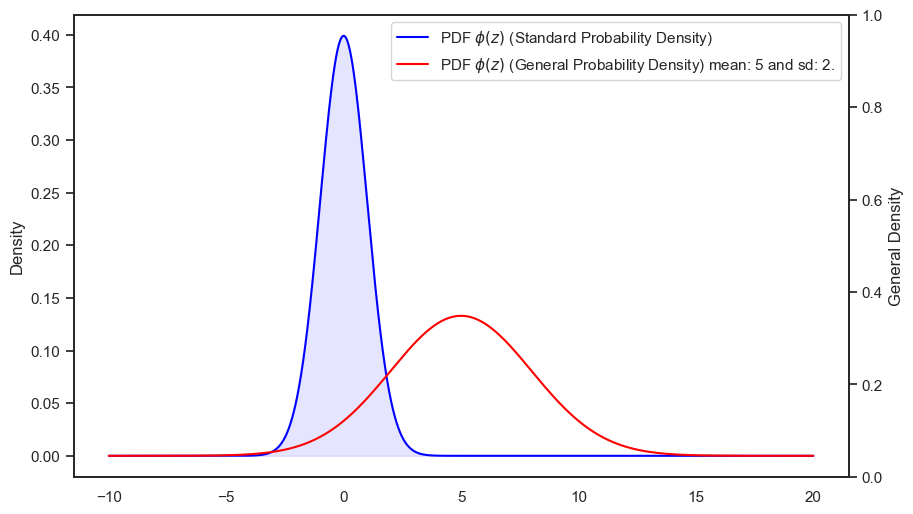

In [14]:
from scipy.stats import norm
import matplotlib.pyplot as plt
import seaborn as sns


x=np.linspace(-10,20,4000)
standard_pdf=norm.pdf(x)
general_pdf=norm.pdf(x,5,3)


fig, ax1 = plt.subplots(figsize=(10, 6))

sns.lineplot(x=x, y=standard_pdf, ax=ax1, color='blue', label='PDF $\phi(z)$ (Standard Probability Density)')
ax1.fill_between(x, standard_pdf, alpha=0.1, color='blue')
ax1.set_ylabel('Density')

ax2=ax1.twinx()
sns.lineplot(x=x, y=general_pdf, ax=ax1, color='red', label='PDF $\phi(z)$ (General Probability Density) mean: 5 and sd: 2.')
ax2.set_ylabel('General Density')

In [1]:
import pandas as pd
df=pd.DataFrame(
    {

    "year":list(range(2015,2020)),
    "observation":[123,39,78,52,100],
    }
)
df['year']=pd.to_datetime(df['year'],format="%Y")
df=df.set_index('year')
df.head()

,observation
year,
2015-01-01,123
2016-01-01,39
2017-01-01,78
2018-01-01,52
2019-01-01,100


In [ ]:
ts_few=pd.to_datetime(["2020-01-01", "2020-01-02", "2020-01-03"])
df=pd.DataFrame({"ts":ts_few})
df=df.assign(period=df['ts'].dt.to_period(),
             yr=df['ts'].dt.year,
             st=df['ts'].dt.strftime("%A, %B %-d"),).set_index("ts")
df

,period,yr,st
ts,,,
2020-01-01,2020-01-01,2020,2020-01-01 00:00:00
2020-01-02,2020-01-02,2020,2020-01-02 00:00:00
2020-01-03,2020-01-03,2020,2020-01-03 00:00:00
